In [ ]:
import pandas as pd

In [ ]:
df =pd.read_csv("/content/ogrenci_uygulama_veri_seti.csv")

In [ ]:
df.head(5)
# ilk 5 satır

,musteri_id,yas,cinsiyet,sehir,egitim_duzeyi,urun_kategorisi,siparis_tutari_tl,siparis_adedi,memnuniyet_puani,iade_durumu
0,O0001,38,Erkek,Ankara,Ön Lisans,Kitap,378.39,5,5,Hayır
1,O0002,39,Kadın,Bursa,Lisans,Kitap,310.43,4,5,Hayır
2,O0003,38,Kadın,İstanbul,Lise,Giyim,1194.27,6,3,Evet
3,O0004,33,Kadın,Ankara,Yüksek Lisans,Ev & Yaşam,586.97,5,4,Hayır
4,O0005,29,Erkek,Ankara,Lise,Ev & Yaşam,111.80,3,5,Hayır


In [ ]:
df.tail(5)
# son 5 satır

,musteri_id,yas,cinsiyet,sehir,egitim_duzeyi,urun_kategorisi,siparis_tutari_tl,siparis_adedi,memnuniyet_puani,iade_durumu
495,O0496,34,Erkek,Antalya,Yüksek Lisans,Spor,270.79,3,4,Hayır
496,O0497,37,Kadın,İzmir,Lisans,Elektronik,499.56,3,5,Hayır
497,O0498,37,Erkek,Antalya,Lisans,Giyim,402.71,2,4,Evet
498,O0499,32,Kadın,İzmir,Lisans,Giyim,703.99,3,5,Evet
499,O0500,40,Kadın,İstanbul,Lise,Ev & Yaşam,190.55,1,4,Hayır


In [ ]:
print(df.shape[0])
# satır sayısı
print(df.shape[1])
# sütun sayısı

500
10


In [ ]:
print("sayısal:", df.select_dtypes(include='number').columns)
print("katagorik:", df.select_dtypes(include='object').columns)
# veri tipi

sayısal: Index(['yas', 'siparis_tutari_tl', 'siparis_adedi', 'memnuniyet_puani'], dtype='object')
katagorik: Index(['musteri_id', 'cinsiyet', 'sehir', 'egitim_duzeyi', 'urun_kategorisi',
       'iade_durumu'],
      dtype='object')


In [ ]:
df.isnull().sum()
# boş değer bulma

,0
musteri_id,0
yas,0
cinsiyet,0
sehir,0
egitim_duzeyi,0
urun_kategorisi,0
siparis_tutari_tl,0
siparis_adedi,0
memnuniyet_puani,0
iade_durumu,0


In [ ]:
from numpy._core import numeric
import pandas as pd
numeric_columns = ['yas', 'siparis_tutari_tl', 'siparis_adedi', 'memnuniyet_puani']
df[numeric_columns].agg(['mean', 'std', 'min', 'max'])
# sayısal degerler için ortalama, std, min deger, max deger bul

,yas,siparis_tutari_tl,siparis_adedi,memnuniyet_puani
mean,32.10200,710.874440,3.438000,3.650000
std,10.12782,782.737161,1.821206,1.087136
min,18.00000,11.270000,1.000000,1.000000
max,65.00000,6953.390000,9.000000,5.000000


In [ ]:
categorical_columns = ['cinsiyet', 'sehir', 'egitim_duzeyi', 'urun_kategorisi', 'iade_durumu']
for col in categorical_columns:
  print( f"\n{col} benzersiz degerler:")
  print(df[col].unique())
  # kategorik degişkenlerin unique degerleri


cinsiyet benzersiz degerler:
['Erkek' 'Kadın']

sehir benzersiz degerler:
['Ankara' 'Bursa' 'İstanbul' 'İzmir' 'Antalya']

egitim_duzeyi benzersiz degerler:
['Ön Lisans' 'Lisans' 'Lise' 'Yüksek Lisans']

urun_kategorisi benzersiz degerler:
['Kitap' 'Giyim' 'Ev & Yaşam' 'Spor' 'Elektronik']

iade_durumu benzersiz degerler:
['Hayır' 'Evet']


In [ ]:
for col in categorical_columns:
  print(f"\n{col} frekans dagılımı:")
  print(df[col].value_counts())

  print(f"\n{col} yüzde dagılımı:")
  print(df[col].value_counts(normalize=True) * 100)
  # kategorik degişkenlerin frekans ve yüzdelik dagılımları


cinsiyet frekans dagılımı:
cinsiyet
Kadın    267
Erkek    233
Name: count, dtype: int64

cinsiyet yüzde dagılımı:
cinsiyet
Kadın    53.4
Erkek    46.6
Name: proportion, dtype: float64

sehir frekans dagılımı:
sehir
İstanbul    185
Ankara       86
Bursa        82
Antalya      77
İzmir        70
Name: count, dtype: int64

sehir yüzde dagılımı:
sehir
İstanbul    37.0
Ankara      17.2
Bursa       16.4
Antalya     15.4
İzmir       14.0
Name: proportion, dtype: float64

egitim_duzeyi frekans dagılımı:
egitim_duzeyi
Lisans           170
Ön Lisans        130
Lise             112
Yüksek Lisans     88
Name: count, dtype: int64

egitim_duzeyi yüzde dagılımı:
egitim_duzeyi
Lisans           34.0
Ön Lisans        26.0
Lise             22.4
Yüksek Lisans    17.6
Name: proportion, dtype: float64

urun_kategorisi frekans dagılımı:
urun_kategorisi
Giyim         128
Elektronik    121
Ev & Yaşam     94
Spor           83
Kitap          74
Name: count, dtype: int64

urun_kategorisi yüzde dagılımı:
urun_kat

In [ ]:
sehir_grup = df.groupby('sehir').agg({
    "siparis_tutari_tl": "mean",
    "memnuniyet_puani": "mean"
})
print(sehir_grup)
# şehirlerin ortalama memnuniyet ve spariş tutarı ortalaması

          siparis_tutari_tl  memnuniyet_puani
sehir                                        
Ankara           679.270116          3.674419
Antalya          748.887143          3.571429
Bursa            785.825000          3.780488
İstanbul         762.410757          3.589189
İzmir            483.886286          3.714286


In [ ]:
urun_toplam = df.groupby('urun_kategorisi')["siparis_adedi"].sum()
print(urun_toplam)
# ürün kategorilerinin toplam spariş adedi

urun_kategorisi
Elektronik    439
Ev & Yaşam    344
Giyim         439
Kitap         240
Spor          257
Name: siparis_adedi, dtype: int64


In [ ]:
iade_tablosu = pd.crosstab(
    [df["cinsiyet"], df["egitim_duzeyi"]],
    df["iade_durumu"],
    normalize="index"
) * 100
print(iade_tablosu)
#cinsiyet ve egitim durumuna göre iade durumunun yüzdelik dagılımı

iade_durumu                  Evet      Hayır
cinsiyet egitim_duzeyi                      
Erkek    Lisans         15.873016  84.126984
         Lise           20.000000  80.000000
         Yüksek Lisans  20.000000  80.000000
         Ön Lisans       8.571429  91.428571
Kadın    Lisans         15.887850  84.112150
         Lise           19.230769  80.769231
         Yüksek Lisans  20.833333  79.166667
         Ön Lisans      11.666667  88.333333


In [ ]:
korelasyon = df["yas"].corr(df["siparis_tutari_tl"])
print("korelasyon:", korelasyon)
# yas ve sparis tutarı arasında korelasyon

korelasyon: 0.047937724287106485


In [ ]:
import matplotlib.pyplot as plt

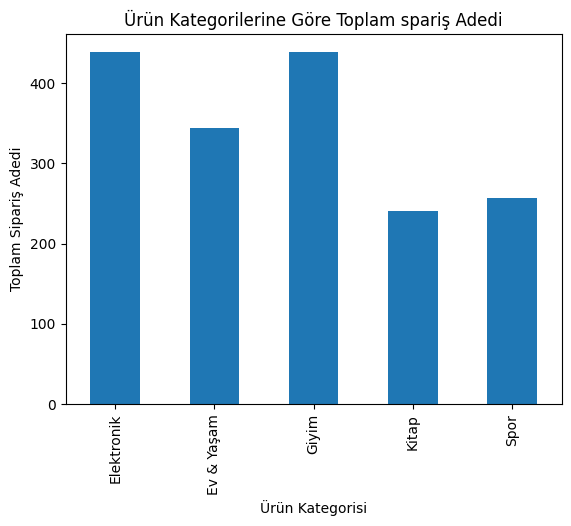

In [ ]:
urun_toplam.plot(kind="bar")
plt.title("Ürün Kategorilerine Göre Toplam spariş Adedi")
plt.xlabel("Ürün Kategorisi")
plt.ylabel("Toplam Sipariş Adedi")
plt.show()
# en çok spariş verilen ürün kategorisi

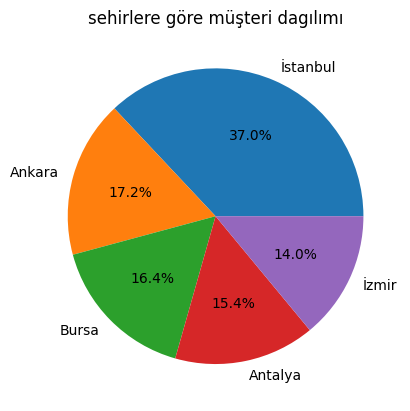

In [ ]:
df["sehir"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("sehirlere göre müşteri dagılımı")
plt.ylabel("")
plt.show()
# sehirlere göre müşteri dagılımı

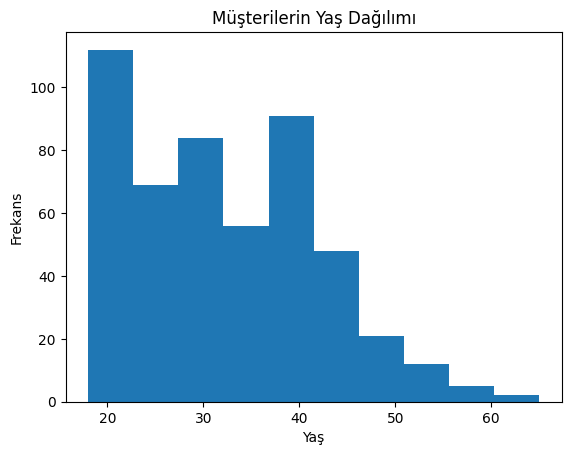

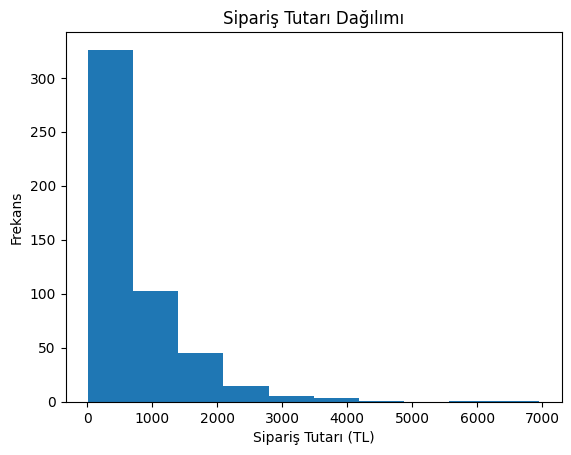

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Veri setini oku
df = pd.read_csv("ogrenci_uygulama_veri_seti.csv")

# Yaş dağılımı histogramı
plt.figure()
plt.hist(df["yas"], bins=10)
plt.title("Müşterilerin Yaş Dağılımı")
plt.xlabel("Yaş")
plt.ylabel("Frekans")
plt.show()

# Sipariş tutarı histogramı
plt.figure()
plt.hist(df["siparis_tutari_tl"], bins=10)
plt.title("Sipariş Tutarı Dağılımı")
plt.xlabel("Sipariş Tutarı (TL)")
plt.ylabel("Frekans")
plt.show()

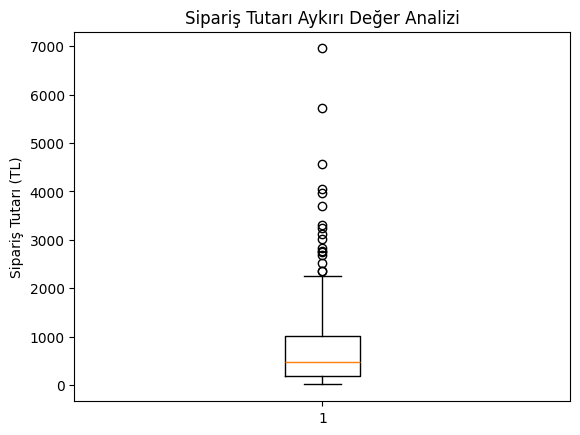

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Veri setini oku
df = pd.read_csv("ogrenci_uygulama_veri_seti.csv")

#  aykırı Sipariş tutarı için kutu grafiği
plt.figure()
plt.boxplot(df["siparis_tutari_tl"])

plt.title("Sipariş Tutarı Aykırı Değer Analizi")
plt.ylabel("Sipariş Tutarı (TL)")

plt.show()

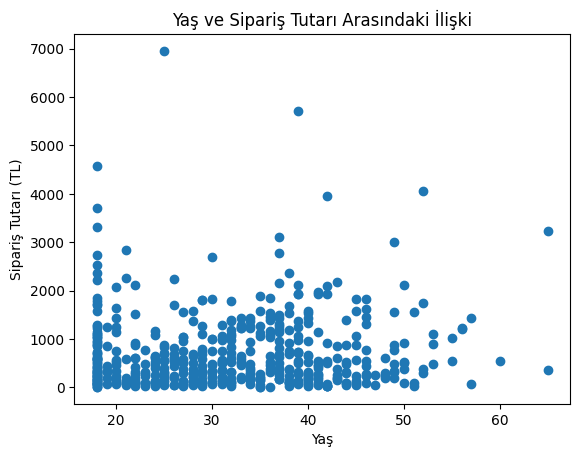

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Veri setini oku
df = pd.read_csv("ogrenci_uygulama_veri_seti.csv")

# yaş ve spariş degişkeni Serpilme diyagramı
plt.figure()
plt.scatter(df["yas"], df["siparis_tutari_tl"])

plt.title("Yaş ve Sipariş Tutarı Arasındaki İlişki")
plt.xlabel("Yaş")
plt.ylabel("Sipariş Tutarı (TL)")

plt.show()

In [ ]:
#Bu e-ticaret şirketinin veri seti incelendiğinde, farklı yaş gruplarından ve şehirlerden müşterilerin alışveriş yaptığı görülmektedir. Sipariş tutarları genellikle belirli bir aralıkta yoğunlaşırken bazı yüksek tutarlı siparişler de bulunmaktadır. Müşteri memnuniyet puanları genel olarak iyi seviyededir. Veri analizi sayesinde şirket müşteri davranışlarını anlayarak satış ve pazarlama stratejilerini geliştirebilir.


In [ ]:
#şirket gelirini artırmak için 36-45 yaş grubuna daha fazla yatırım yapmalıdır çünkü en yüksek sipariş tutarı bu grupta görülmektedir. Şehir olarak İstanbul en yüksek satışın olduğu yerdir, bu nedenle pazarlama ve reklam yatırımı burada artırılabilir. Ürün kategorilerinde ise elektronik ürünler en fazla geliri sağladığı için şirketin bu kategoriye daha fazla odaklanması önerilir.

In [ ]:
# ürünler gönderilmeden önce kalite kontrol yapılmalı.
#ürün hakkında daha açıklayıcı fotograf ve yazı olmalı.
#müşteri geri bildirimini analiz edip soruna odaklı eylemler gerçekleştirilmeli.